<a href="https://colab.research.google.com/github/jainpalak1406-cpu/Design-and-Analysis-of-Algorithms-Lab/blob/main/DAA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

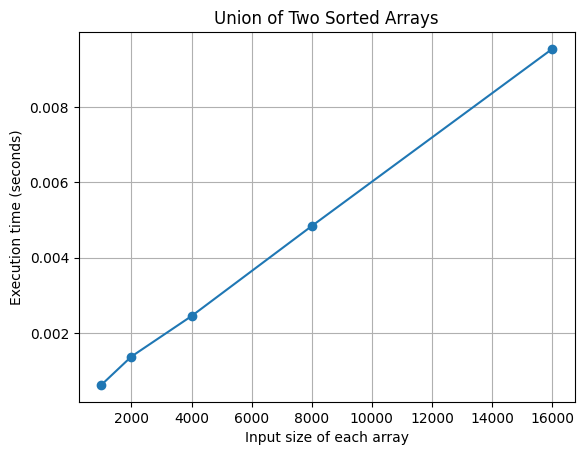

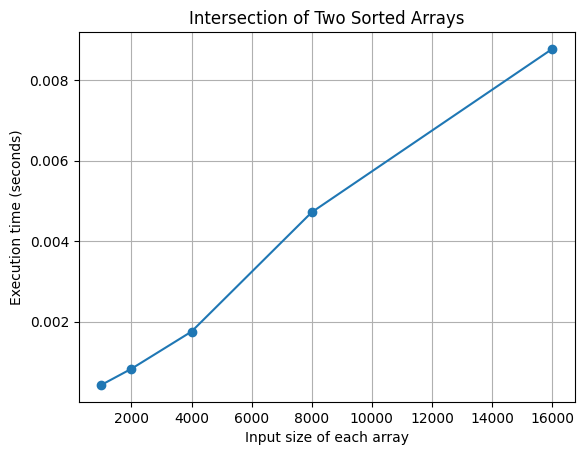

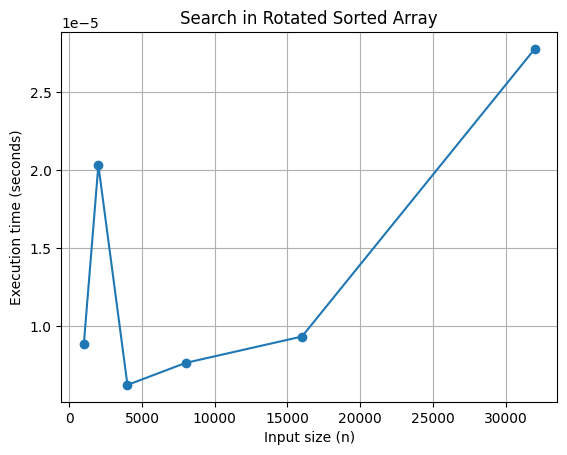

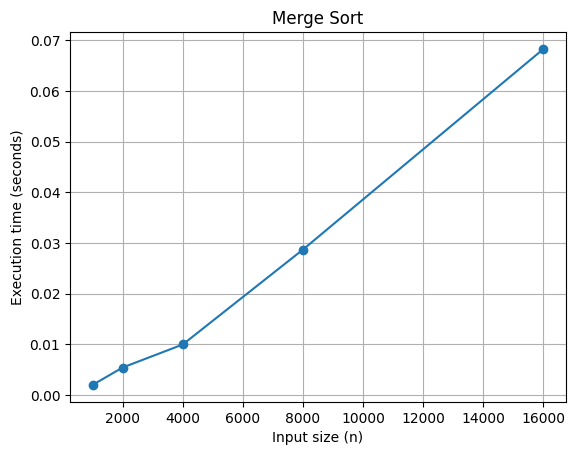

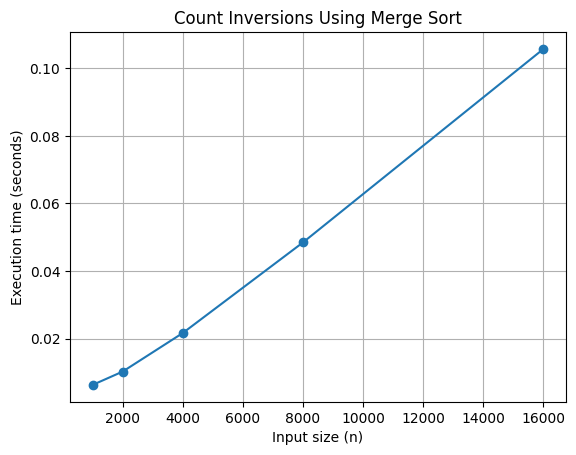

In [1]:
import random
import time
import matplotlib.pyplot as plt
import numpy as np

# DIVIDE AND CONQUER ON ARRAY

# Union of two sorted arrays
def union_array(A, B):
    i = 0
    j = 0
    result = []

    while i < len(A) and j < len(B):

        if A[i] < B[j]:
            if len(result) == 0 or result[-1] != A[i]:
                result.append(A[i])
            i += 1

        elif B[j] < A[i]:
            if len(result) == 0 or result[-1] != B[j]:
                result.append(B[j])
            j += 1

        else:
            if len(result) == 0 or result[-1] != A[i]:
                result.append(A[i])
            i += 1
            j += 1

    while i < len(A):
        if len(result) == 0 or result[-1] != A[i]:
            result.append(A[i])
        i += 1

    while j < len(B):
        if len(result) == 0 or result[-1] != B[j]:
            result.append(B[j])
        j += 1

    return result


sizes = [1000, 2000, 4000, 8000, 16000]
times = []

for n in sizes:

    A = list(range(0, n * 2, 2))
    B = list(range(1, n * 2, 2))

    start = time.perf_counter()
    union_array(A, B)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Input size of each array")
plt.ylabel("Execution time (seconds)")
plt.title("Union of Two Sorted Arrays")
plt.grid(True)
plt.show()


# Intersection of two sorted arrays
def intersection_array(A, B):
    i = 0
    j = 0
    result = []

    while i < len(A) and j < len(B):

        if A[i] < B[j]:
            i += 1

        elif B[j] < A[i]:
            j += 1

        else:
            if len(result) == 0 or result[-1] != A[i]:
                result.append(A[i])

            i += 1
            j += 1

    return result


sizes = [1000, 2000, 4000, 8000, 16000]
times = []

for n in sizes:

    A = list(range(0, n))
    B = list(range(n // 2, n + n // 2))

    start = time.perf_counter()
    intersection_array(A, B)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Input size of each array")
plt.ylabel("Execution time (seconds)")
plt.title("Intersection of Two Sorted Arrays")
plt.grid(True)
plt.show()


# Search in a rotated sorted array
def search_rotated(arr, target):
    low = 0
    high = len(arr) - 1

    while low <= high:

        mid = (low + high) // 2

        if arr[mid] == target:
            return mid

        if arr[low] <= arr[mid]:

            if arr[low] <= target < arr[mid]:
                high = mid - 1
            else:
                low = mid + 1

        else:

            if arr[mid] < target <= arr[high]:
                low = mid + 1
            else:
                high = mid - 1

    return -1


sizes = [1000, 2000, 4000, 8000, 16000, 32000]
times = []

for n in sizes:

    arr = list(range(n))

    rotation = n // 3
    arr = arr[rotation:] + arr[:rotation]

    target = n - 1

    start = time.perf_counter()
    search_rotated(arr, target)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Input size (n)")
plt.ylabel("Execution time (seconds)")
plt.title("Search in Rotated Sorted Array")
plt.grid(True)
plt.show()


# Merge sort
def merge_sort(arr):

    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    result = []

    i = 0
    j = 0

    while i < len(left) and j < len(right):

        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result


sizes = [1000, 2000, 4000, 8000, 16000]
times = []

for n in sizes:

    arr = random.sample(range(n * 2), n)

    start = time.perf_counter()
    merge_sort(arr)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Input size (n)")
plt.ylabel("Execution time (seconds)")
plt.title("Merge Sort")
plt.grid(True)
plt.show()



# Count inversions using merge sort
def merge_and_count(left, right):

    i = 0
    j = 0
    count = 0
    result = []

    while i < len(left) and j < len(right):

        if left[i] <= right[j]:
            result.append(left[i])
            i += 1

        else:
            result.append(right[j])
            count += len(left) - i
            j += 1

    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result, count


def count_inversions(arr):

    if len(arr) <= 1:
        return arr, 0

    mid = len(arr) // 2

    left, left_count = count_inversions(arr[:mid])
    right, right_count = count_inversions(arr[mid:])

    merged, merge_count = merge_and_count(left, right)

    total = left_count + right_count + merge_count

    return merged, total


sizes = [1000, 2000, 4000, 8000, 16000]
times = []

for n in sizes:

    arr = random.sample(range(n * 2), n)

    start = time.perf_counter()
    count_inversions(arr)
    end = time.perf_counter()

    times.append(end - start)

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel("Input size (n)")
plt.ylabel("Execution time (seconds)")
plt.title("Count Inversions Using Merge Sort")
plt.grid(True)
plt.show()
